## Cricket is gentelman game.
## it is played 12 coutries
## this game is not part of olympics
## every four there is worldcup
## in india cooking is done mostly by females
## most of people prefer vegeterian food
## indian prefer spicy foods
## cybersecurity is important subject
## but not every one takes interest in it
## because it is technical subject

In [8]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


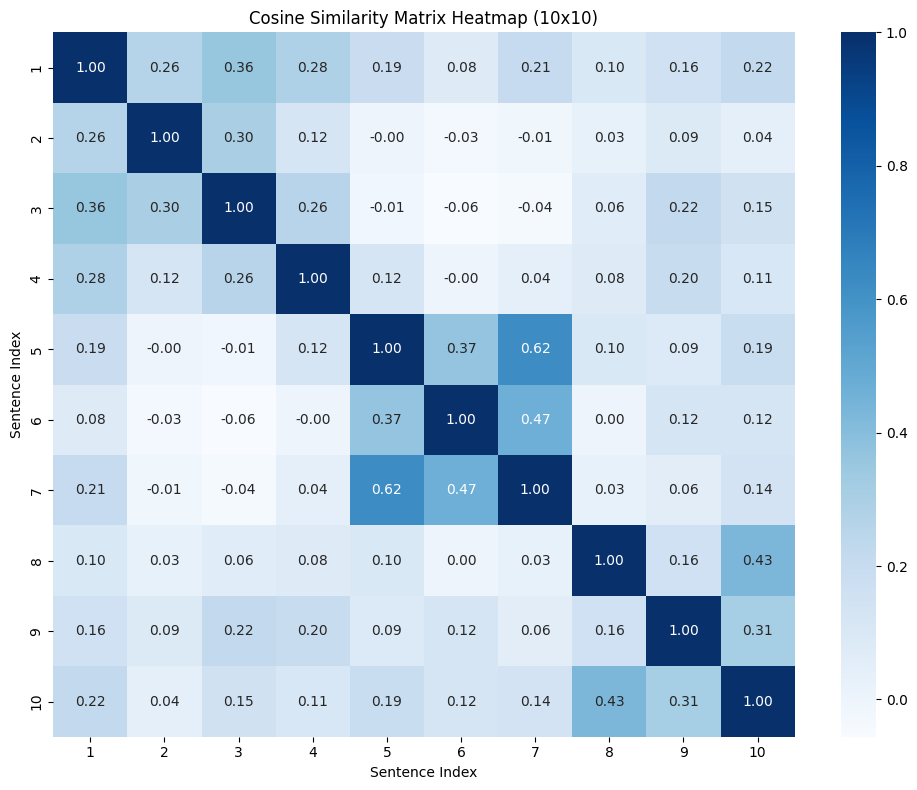

In [12]:
sentences = [
"Cricket is gentelman game.",
"it is played 12 coutries.",
"this game is not part of olympics.",
"every four years there is worldcup.",
"in india cooking is done mostly by females.",
"most of people prefer vegeterian food.",
"indian prefer spicy foods.",
"cybersecurity is important subject.",
"but not every one takes interest in it.",
"because it is technical subject.",
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

cos_sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    cos_sim_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    xticklabels=range(1, 11),
    yticklabels=range(1, 11)
)
plt.title('Cosine Similarity Matrix Heatmap (10x10)')
plt.xlabel('Sentence Index')
plt.ylabel('Sentence Index')
plt.tight_layout()
plt.show()


## Given this new query sentence — "The bowler took three wickets in one over" — find and print the top 2 most similar sentences from your set with their similarity scores

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


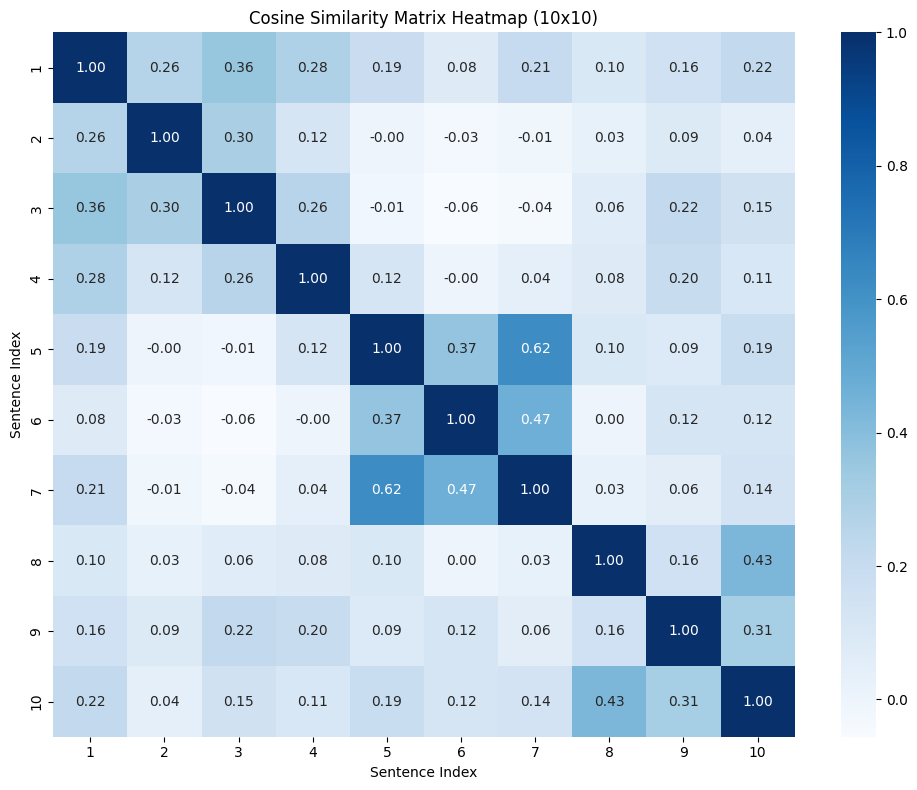


Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
--------------------------------------------------
Rank 1 | Score: 0.3539 | Sentence 1: "Cricket is gentelman game."
Rank 2 | Score: 0.1430 | Sentence 7: "indian prefer spicy foods."


In [15]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

sentences = [
    "Cricket is gentelman game.",
    "it is played 12 coutries.",
    "this game is not part of olympics.",
    "every four years there is worldcup.",
    "in india cooking is done mostly by females.",
    "most of people prefer vegeterian food.",
    "indian prefer spicy foods.",
    "cybersecurity is important subject.",
    "but not every one takes interest in it.",
    "because it is technical subject.",
]

# ── 1. Generate Embeddings ──────────────────────────────────────────
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

# ── 2. Cosine Similarity Heatmap ────────────────────────────────────
cos_sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    cos_sim_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    xticklabels=range(1, 11),
    yticklabels=range(1, 11)
)
plt.title('Cosine Similarity Matrix Heatmap (10x10)')
plt.xlabel('Sentence Index')
plt.ylabel('Sentence Index')
plt.tight_layout()
plt.show()

# ── 3. Top 2 Most Similar Sentences to Query ────────────────────────
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

query_similarities = util.cos_sim(query_embedding, embeddings)[0]

top2 = torch.topk(query_similarities, k=2)

print(f"\nQuery: '{query}'\n")
print("Top 2 most similar sentences:")
print("-" * 50)
for rank, (score, idx) in enumerate(zip(top2.values, top2.indices), start=1):
    print(f"Rank {rank} | Score: {score:.4f} | Sentence {idx+1}: \"{sentences[idx]}\"")


